### Importing dependencies


In [3]:
import json
import gzip
import pandas as pd

### Working with downloaded data

In [4]:
with gzip.open('../../data/meta_Electronics.jsonl.gz', 'rt') as f:
    first_line = json.loads(f.readline())

first_line

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

### Filter out only recent items (2022-2023)


In [5]:
def filter_data_by_data(data: dict) -> bool:
    filter = False
    if int(data['details']['Date First Available'][-4:]) < 2022:
        filter = True

    return filter

In [6]:
with gzip.open('../../data/meta_Electronics.jsonl.gz', 'rt') as fp:
    with open('../../data/meta_Electronics_recent_2022_2023.jsonl', 'a', encoding='utf-8') as fp_out:
        with open('../../data/meta_Electronics_recent_2022_2023_no_date.jsonl', 'a', encoding='utf-8') as fp_out_no_date:
            i=0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data_by_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write('\n')
                    fp_out_no_date.flush()
                i+=1
                if i % 100000 == 0:
                    print(f'{i} lines processed')

100000 lines processed
200000 lines processed
300000 lines processed
400000 lines processed
500000 lines processed
600000 lines processed
700000 lines processed
800000 lines processed
900000 lines processed
1000000 lines processed
1100000 lines processed
1200000 lines processed
1300000 lines processed
1400000 lines processed
1500000 lines processed
1600000 lines processed


### Split items into two categories: "has_main_category" and "no_main_category"

In [7]:
def filter_category(data: dict) -> bool:
    filter = False
    if data['main_category'] == None:
        filter = True
    return filter

In [9]:
with open('../../data/meta_Electronics_recent_2022_2023.jsonl', 'r') as fp:
    with open('../../data/meta_Electronics_recent_2022_2023_has_main_category.jsonl', 'a', encoding='utf-8') as fp_out:
        with open('../../data/meta_Electronics_recent_2022_2023_no_main_category.jsonl', 'a', encoding='utf-8') as fp_out_no_main_category:
            i=0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_category(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_main_category)
                    fp_out_no_main_category.write('\n')
                    fp_out_no_main_category.flush()
                i+=1
                if i % 100000 == 0:
                    print(f'{i} lines processed')

100000 lines processed


### Explore data distribution by categories

#### 1. Load Data

In [10]:
df = pd.read_json('../../data/meta_Electronics_recent_2022_2023_has_main_category.jsonl', lines=True)

In [11]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Amazon Home,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,50,[PROFESSIONAL STICKER SHOP.There are 50 differ...,"[Features:, - Clear picture and exquisite prin...",3.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Watch Before Buying! Huge Waterpro...,Affoto,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Affoto', 'Color': 'Outer Space', 'S...",B0BPLX8B2K,NaN,NaN,NaN
1,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN,NaN,NaN
2,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN,NaN,NaN
3,All Electronics,"LENTION USB C Docking Station, 10 Gbps USB C&U...",4.4,16,[10-in-1 Docking Station - CB-D65 laptop docki...,[],89.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'LENTION D65 Upgrade Docking Statio...,LENTION,"[Electronics, Computers & Accessories, Laptop ...",{'Package Dimensions': '9.17 x 4.33 x 1.54 inc...,B0BKS1K986,NaN,NaN,NaN
4,All Electronics,1X (No Bluetooth) Eaglewireless Replacement To...,3.0,4,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eaglewireless,[],{'Package Dimensions': '5.2 x 2.13 x 0.91 inch...,B09MY246CC,NaN,NaN,NaN


<Axes: xlabel='main_category'>

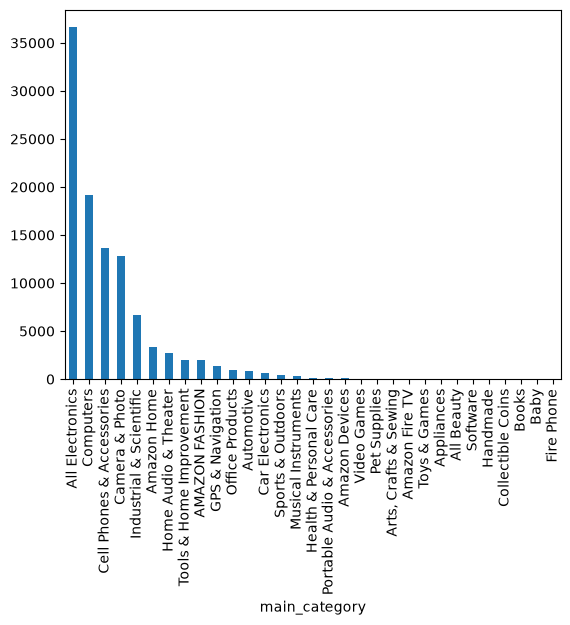

In [12]:
df['main_category'].value_counts().plot(kind='bar')

#### 2. Filter out items that have at least 100 ratings

In [14]:
df_ratings_100 = df[df['rating_number'] >= 100]
len(df_ratings_100)

17290

<Axes: xlabel='main_category'>

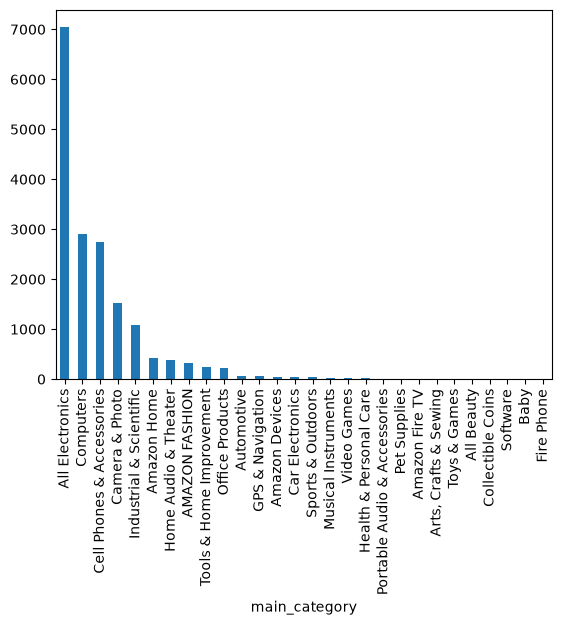

In [15]:
df_ratings_100['main_category'].value_counts().plot(kind='bar')

#### 2. Explore Distribution of Ratings

<Axes: ylabel='Frequency'>

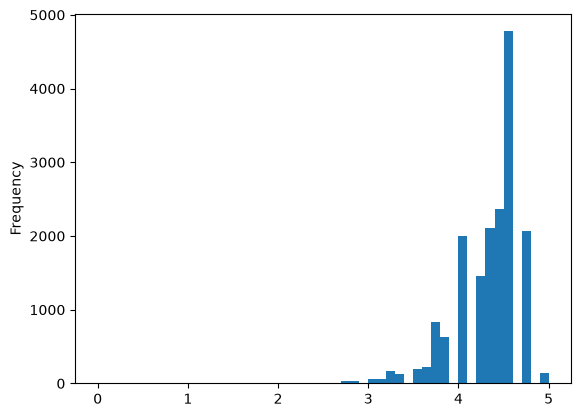

In [16]:
df_ratings_100['average_rating'].plot(kind='hist', bins=50, range=(0,5))

#### 3. Sample 1000 items and check average rating distribution

In [17]:
df_sample_1000 = df_ratings_100.sample(1000, random_state=42)

<Axes: ylabel='Frequency'>

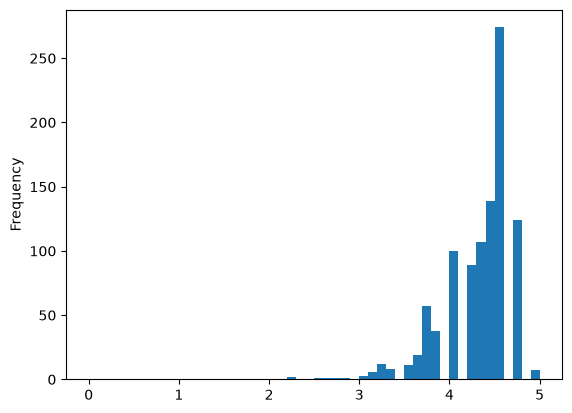

In [18]:
df_sample_1000['average_rating'].plot(kind='hist', bins=50, range=(0,5))

#### 4. Save datasets as json files for future use

In [19]:
df_ratings_100.to_json('../../data/meta_Electronics_recent_2022_2023_has_main_category_ratings_100.jsonl', orient='records', lines=True)
df_sample_1000.to_json('../../data/meta_Electronics_recent_2022_2023_has_main_category_ratings_100_sample_1000.jsonl', orient='records', lines=True)

#### 5. Extract ratings that match sampled data

In [21]:
df_ratings_100 = pd.read_json('../../data/meta_Electronics_recent_2022_2023_has_main_category_ratings_100.jsonl', lines=True)
df_sample_1000 = pd.read_json('../../data/meta_Electronics_recent_2022_2023_has_main_category_ratings_100_sample_1000.jsonl', lines=True)

In [22]:
with gzip.open('../../data/Electronics.jsonl.gz', 'r') as fp:
    with open('../../data/Electronics_recent_2022_2023_has_main_category_ratings_100_sample_1000.jsonl', 'a', encoding='utf-8') as fp_out:
        id_list = set(df_sample_1000['parent_asin'].values)
        i=0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data, fp_out)
                fp_out.write('\n')
                fp_out.flush()
            i+=1
            if i % 100000 == 0:
                print(f'{i} lines processed')

100000 lines processed
200000 lines processed
300000 lines processed
400000 lines processed
500000 lines processed
600000 lines processed
700000 lines processed
800000 lines processed
900000 lines processed
1000000 lines processed
1100000 lines processed
1200000 lines processed
1300000 lines processed
1400000 lines processed
1500000 lines processed
1600000 lines processed
1700000 lines processed
1800000 lines processed
1900000 lines processed
2000000 lines processed
2100000 lines processed
2200000 lines processed
2300000 lines processed
2400000 lines processed
2500000 lines processed
2600000 lines processed
2700000 lines processed
2800000 lines processed
2900000 lines processed
3000000 lines processed
3100000 lines processed
3200000 lines processed
3300000 lines processed
3400000 lines processed
3500000 lines processed
3600000 lines processed
3700000 lines processed
3800000 lines processed
3900000 lines processed
4000000 lines processed
4100000 lines processed
4200000 lines processed
4